# 01. Microscopic Breakdown and the Parity-Gap Lemma

Reproduces the numerical evidence in §2.2 (parity-lex collapse of $Q_3$),
§3 (Parity-Gap Lemma + Theorem 1), and Appendix A.2 (defect-density sweep
$k\le5000$).

**Headline results:**
- $Q_3$ at shift $m=22$ is defective at $n=31$ (parity flip with 7 R's in
  the prefix).
- $Q_5$ at shift $m=112$ is defective at the prime gap 113→127.
- For $k\in\{1,\ldots,5000\}\setminus\{3,5\}$, $\rho(N)=0$ exactly
  (Conjecture: Finite-defect spectrum).


In [1]:
# add project root to path so we can import src/
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")


project root: /root/autodl-tmp/prime_math


In [2]:
from src.sieve import Qk_sequence, Qk_horizon, first_n_primes
from src.mss import count_defects
import numpy as np

# Verify the Q_3 microscopic counter-example by hand
N = Qk_horizon(3)            # 49
seq = Qk_sequence(3, N)
print(f"Q_3 first 10 symbols (R=1, L=0): {seq[:10].tolist()}")
print(f"  positions 0..9 in numbers:    {list(range(10))}")
print(f"  L-positions (primes/coprime to 2,3,5): {np.where(seq==0)[0].tolist()[:6]}")

# Compare Q_3 vs sigma^22(Q_3)
shift = 22
orig = seq[:10]
shifted = seq[shift:shift+10]
print(f"\nQ_3 at i=0..9         : {orig.tolist()}")
print(f"sigma^22(Q_3) at i=0..9: {shifted.tolist()}")

# First 9 agree; 10th (position 9 = n=31 prime) is the conflict
diffs = orig != shifted
first_diff = int(np.argmax(diffs))
r_count = int(orig[:first_diff].sum())
print(f"\nFirst disagreement at position {first_diff} (i.e. n={shift+first_diff}={shift+first_diff})")
print(f"R-count in common prefix: {r_count} (odd -> parity flip applies)")
print(f"Q_3[{first_diff}]={orig[first_diff]} (R), sigma^22(Q_3)[{first_diff}]={shifted[first_diff]} (L)")
print(f"Under flipped order R<L, Q_3 < sigma^22(Q_3) -> defect confirmed")


Q_3 first 10 symbols (R=1, L=0): [1, 0, 1, 1, 1, 1, 1, 0, 1, 1]
  positions 0..9 in numbers:    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  L-positions (primes/coprime to 2,3,5): [1, 7, 11, 13, 17, 19]

Q_3 at i=0..9         : [1, 0, 1, 1, 1, 1, 1, 0, 1, 1]
sigma^22(Q_3) at i=0..9: [1, 0, 1, 1, 1, 1, 1, 0, 1, 0]

First disagreement at position 9 (i.e. n=31=31)
R-count in common prefix: 7 (odd -> parity flip applies)
Q_3[9]=1 (R), sigma^22(Q_3)[9]=0 (L)
Under flipped order R<L, Q_3 < sigma^22(Q_3) -> defect confirmed


In [3]:
# Defect-density sweep for k = 1..14 (small horizon, fast)
defects, rhos = [], []
for k in range(1, 15):
    N = Qk_horizon(k)
    seq = Qk_sequence(k, N)
    d, rho = count_defects(seq)
    defects.append(d); rhos.append(rho)
    pk = first_n_primes(k)[k-1]
    print(f"  k={k:>2}  p_k={pk:>3}  N={N:>5}  defects={d}  rho(N)={rho:.4e}")


  k= 1  p_k=  2  N=    9  defects=0  rho(N)=0.0000e+00
  k= 2  p_k=  3  N=   25  defects=0  rho(N)=0.0000e+00
  k= 3  p_k=  5  N=   49  defects=1  rho(N)=2.0833e-02
  k= 4  p_k=  7  N=  121  defects=0  rho(N)=0.0000e+00
  k= 5  p_k= 11  N=  169  defects=1  rho(N)=5.9524e-03
  k= 6  p_k= 13  N=  289  defects=0  rho(N)=0.0000e+00
  k= 7  p_k= 17  N=  361  defects=0  rho(N)=0.0000e+00
  k= 8  p_k= 19  N=  529  defects=0  rho(N)=0.0000e+00
  k= 9  p_k= 23  N=  841  defects=0  rho(N)=0.0000e+00
  k=10  p_k= 29  N=  961  defects=0  rho(N)=0.0000e+00
  k=11  p_k= 31  N= 1369  defects=0  rho(N)=0.0000e+00
  k=12  p_k= 37  N= 1681  defects=0  rho(N)=0.0000e+00
  k=13  p_k= 41  N= 1849  defects=0  rho(N)=0.0000e+00
  k=14  p_k= 43  N= 2209  defects=0  rho(N)=0.0000e+00


**Observation**: defects appear *only* at $k=3$ and $k=5$. All other
stages within their physical horizon are MSS-admissible. This is what
the paper's Conjecture (Finite-defect spectrum) asserts at full sweep
scale; the verified range goes to $k=5000$ in `experiments/exp1_large.py`
(too slow to re-run here — read `results/exp1_large.csv` for the cached
output).


In [4]:
import pathlib, csv

csv_path = ROOT / "results" / "exp1_large.csv"
if csv_path.exists():
    rows = list(csv.DictReader(csv_path.open()))
    print(f"Cached k=1..{len(rows)} sweep:")
    defective = [r for r in rows if int(r["defects"]) > 0]
    print(f"  Total stages: {len(rows)}")
    print(f"  Defective stages: {len(defective)}")
    for r in defective:
        print(f"    k={r['k']}, p_k={r['p_k']}, N={r['horizon_N']}, defects={r['defects']}, rho={float(r['rho_N']):.4e}")
else:
    print("results/exp1_large.csv not found; run experiments/exp1_large.py first")


Cached k=1..5000 sweep:
  Total stages: 5000
  Defective stages: 2
    k=3, p_k=5, N=49, defects=1, rho=2.0833e-02
    k=5, p_k=11, N=169, defects=1, rho=5.9524e-03


## Parity-Gap Lemma (numerical verification)

Theorem (Parity-Gap Lemma): if $W_k$ has a defective shift $m$, then
(i) $m+1$ is prime, and (ii) the next prime > $m+1$ is at least
$m+p_{k+1}$ (i.e. the prime gap there is $\geq p_{k+1}-1$).

For $Q_3$ ($p_4=7$): defective $m=22$, $m+1=23$ prime, next prime 29,
gap $= 6 \geq p_4-1 = 6$ ✓ (saturates exactly).

For $Q_5$ ($p_6=13$): defective $m=112$, $m+1=113$ prime, next prime
127, gap $= 14 \geq p_6-1 = 12$ ✓.


In [5]:
from sympy import isprime, nextprime

for k, m in [(3, 22), (5, 112)]:
    pk1 = first_n_primes(k)[k]   # p_{k+1}
    print(f"Q_{k}, defective shift m={m}:")
    print(f"  m+1 = {m+1}, prime? {isprime(m+1)}")
    np_ = nextprime(m+1)
    gap = np_ - (m+1)
    print(f"  next prime after {m+1} is {np_}, gap = {gap}")
    print(f"  Parity-Gap demands gap >= p_{{k+1}}-1 = {pk1-1}: {'OK' if gap >= pk1-1 else 'FAIL'}")
    print()


Q_3, defective shift m=22:
  m+1 = 23, prime? True
  next prime after 23 is 29, gap = 6
  Parity-Gap demands gap >= p_{k+1}-1 = 6: OK

Q_5, defective shift m=112:
  m+1 = 113, prime? True
  next prime after 113 is 127, gap = 14
  Parity-Gap demands gap >= p_{k+1}-1 = 12: OK



## Visualisation: defect density $\rho(N)$

See `figures/fig3_defect_density.png` (built by `figures/fig3_defect_density.py`).


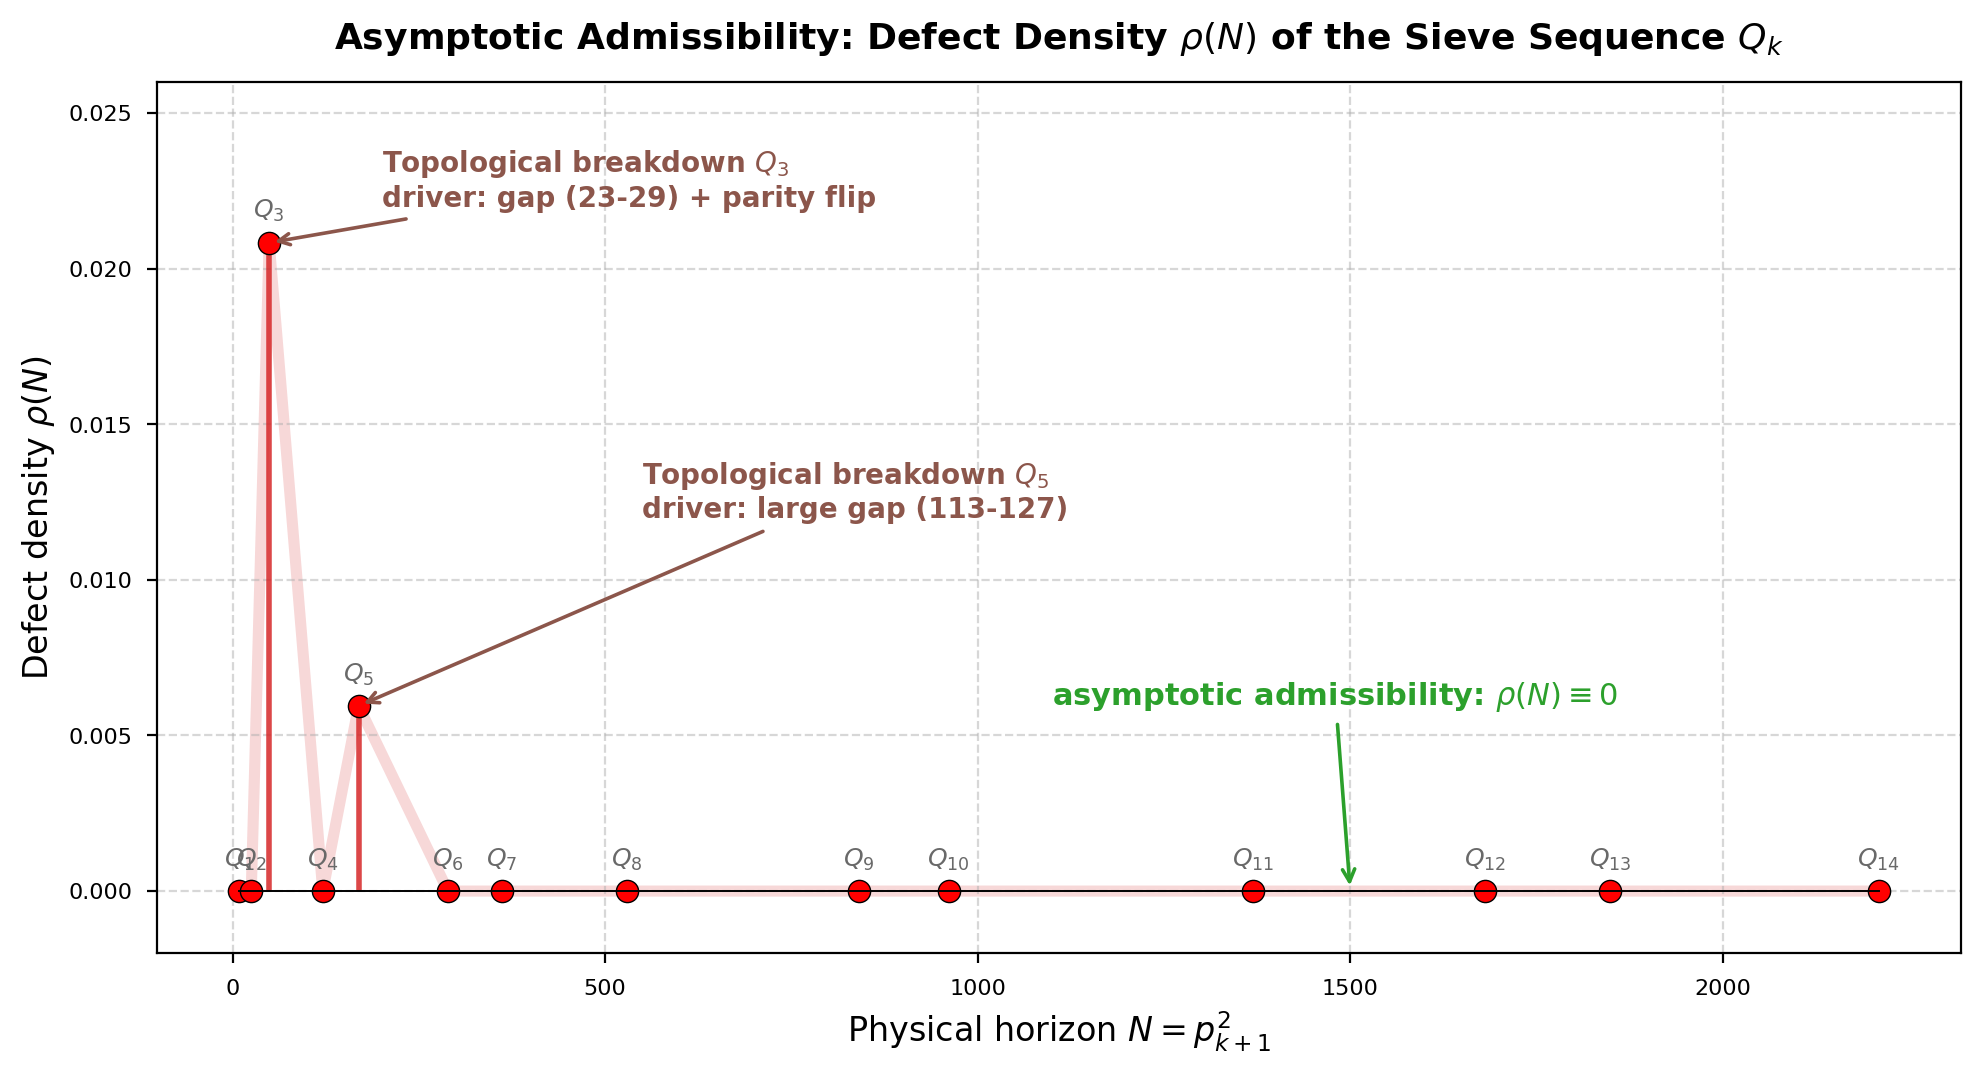

In [6]:
from IPython.display import Image, display
fig_path = ROOT / "figures" / "fig3_defect_density.png"
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print(f"figure not found: {fig_path}")
